# Experiment 5: Perceptron vs Multilayer Perceptron with Hyperparameter Tuning

Name: Kushaal Shyam Potta

Reg. No: 3122235001071


In [48]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

1. Preprocess the dataset (resize, flatten, normalize).

In [ ]:
img_folder = r"dataset/Img"
df = pd.read_csv("dataset/english.csv")

# List to store dimensions
dimensions = []

for path in df['image']:
    # Get the filename and full path
    img_file = os.path.basename(path)
    img_path = os.path.join(img_folder, img_file)
    
    # Load image in grayscale as specified in the experiment
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        h, w = img.shape  # This gives you (height, width)
        dimensions.append((h, w))
    else:
        dimensions.append((None, None))


In [ ]:
print(dimensions)

#all images are of dimension 900x1200

[(900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200), (900, 1200)

In [9]:
def load_and_process_data(csv_path, img_folder, target_size=(40,30)):
    df = pd.read_csv(csv_path)
    X,y=[],[]

    print("Downscaling and Flattening images...")

    for index,row in df.iterrows():
        img_path=os.path.join(img_folder, os.path.basename(row['image']))
        img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img_resized=cv2.resize(img, target_size)
            img_flattened = img_resized.flatten()
            X.append(img_flattened/255.0)
            y.append(row['label'])

    return np.array(X), np.array(y)

X,y=load_and_process_data("dataset/english.csv", img_folder)

le=LabelEncoder()
y_encoded=le.fit_transform(y)
num_classes=len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, shuffle=True, stratify=y_encoded)


Downscaling and Flattening images...


In [8]:
print(num_classes)

62


2. Implement PLA from scratch:

• Use step activation function.

• Apply perceptron weight update rule.

• Extend PLA to multi-class classification using One-vs-Rest

In [15]:
class PLA:
    def __init__(self,learning_rate=0.01,epochs=10):
        self.lr=learning_rate
        self.epochs = epochs
        self.weights=None
        self.bias=0

    def step_activation(self, z):
        return 1 if z>=0 else 0
    
    def fit(self, X,y):
        num_samples, num_features= X.shape
        self.weights=np.zeros(num_features)
        self.bias=0

        for epoch in range(self.epochs):
            for i,x_i in enumerate(X):
                linear_output = np.dot(x_i,self.weights) + self.bias

                y_predicted=self.step_activation(linear_output)

                update = self.lr*(y[i]-y_predicted)
                self.weights+=update*x_i
                self.bias+=update

    def get_score(self,X):
        """Return raw dot product to determine confidence for OvR"""
        return np.dot(X,self.weights) + self.bias



In [12]:
class PLA_MultiClass:
    def __init__(self,num_classes,lr=0.01,epochs=10):
        self.num_classes=num_classes
        self.lr=lr
        self.epochs=epochs
        self.models=[]

    def fit(self, X,y):

        for i in range(num_classes):

            y_binary=np.where(y==i,1,0)

            model=PLA(learning_rate=self.lr,epochs=self.epochs)
            model.fit(X,y_binary)

            self.models.append(model)

            if (i+1)%10==0:
                print(f"Trained {i+1}/{self.num_classes} binary classifiers")

    def predict(self,X):
        all_scores=np.array([model.get_score(X) for model in self.models])
        # .T helps flip the images as rows and then compare/find max
        return np.argmax(all_scores.T,axis=1)


In [ ]:
pla=PLA_MultiClass(num_classes=62,lr=0.01,epochs=15)

print("starting pla training...")
pla.fit(X_train,y_train)

y_pred=pla.predict(X_test)

starting pla training...
Trained 10/62 binary classifiers
Trained 20/62 binary classifiers
Trained 30/62 binary classifiers
Trained 40/62 binary classifiers
Trained 50/62 binary classifiers
Trained 60/62 binary classifiers
PLA Accuracy: 13.39%

Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.12      0.07        16
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        17
           3       0.75      0.19      0.30        16
           4       0.00      0.00      0.00        16
           5       0.00      0.00      0.00        16
           6       0.00      0.00      0.00        16
           7       0.00      0.00      0.00        17
           8       0.06      0.06      0.06        16
           9       1.00      0.06      0.12        16
          10       0.67      0.12      0.20        17
          11       0.09      0.35      0.15        17
          12       0.67      

/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [24]:
print(f"PLA Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"PLA Precision (Macro): {precision_score(y_test, y_pred,average='macro') * 100:.2f}%")
print(f"PLA F1 Score (Macro): {f1_score(y_test, y_pred,average='macro') * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

PLA Accuracy: 13.39%
PLA Precision (Macro): 22.44%
PLA F1 Score (Macro): 11.07%

Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.12      0.07        16
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        17
           3       0.75      0.19      0.30        16
           4       0.00      0.00      0.00        16
           5       0.00      0.00      0.00        16
           6       0.00      0.00      0.00        16
           7       0.00      0.00      0.00        17
           8       0.06      0.06      0.06        16
           9       1.00      0.06      0.12        16
          10       0.67      0.12      0.20        17
          11       0.09      0.35      0.15        17
          12       0.67      0.38      0.48        16
          13       0.00      0.00      0.00        16
          14       0.00      0.00      0.00        17
          15       0.00      0.

/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

3. Implement MLP:

• Select number of hidden layers and neurons.

• Choose activation functions.

• Train using backpropagation.

In [39]:
clf_1=MLPClassifier(
    random_state=42,
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='sgd',
    learning_rate='constant',
    alpha=0.01,
    batch_size=32
)

clf_1.fit(X_train,y_train)

y_pred_clf1=clf_1.predict(X_test)

/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [40]:
print(f"MLP 1 Accuracy: {accuracy_score(y_test, y_pred_clf1) * 100:.2f}%")
print(f"MLP 1 Precision (Macro): {precision_score(y_test, y_pred_clf1,average='macro') * 100:.2f}%")
print(f"MLP 1 F1 Score (Macro): {f1_score(y_test, y_pred_clf1,average='macro') * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_clf1))

MLP 1 Accuracy: 35.19%
MLP 1 Precision (Macro): 36.65%
MLP 1 F1 Score (Macro): 33.78%

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.25      0.22        16
           1       0.24      0.35      0.29        17
           2       0.60      0.35      0.44        17
           3       0.24      0.31      0.27        16
           4       0.00      0.00      0.00        16
           5       0.25      0.12      0.17        16
           6       0.33      0.44      0.38        16
           7       0.29      0.35      0.32        17
           8       0.31      0.25      0.28        16
           9       0.32      0.50      0.39        16
          10       0.46      0.65      0.54        17
          11       0.50      0.24      0.32        17
          12       0.61      0.69      0.65        16
          13       0.40      0.38      0.39        16
          14       0.28      0.41      0.33        17
          15       0.41  

In [35]:
clf_2=MLPClassifier(
    random_state=42,
    hidden_layer_sizes=(256,128,),
    activation='relu',
    solver='adam',
    learning_rate='constant',
    alpha=0.001,
    batch_size=64
)

clf_2.fit(X_train,y_train)

y_pred_clf2=clf_2.predict(X_test)

/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [42]:
print(f"MLP 2 Accuracy: {accuracy_score(y_test, y_pred_clf2) * 100:.2f}%")
print(f"MLP 2 Precision (Macro): {precision_score(y_test, y_pred_clf2,average='macro') * 100:.2f}%")
print(f"MLP 2 F1 Score (Macro): {f1_score(y_test, y_pred_clf2,average='macro') * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_clf2))

MLP 2 Accuracy: 38.03%
MLP 2 Precision (Macro): 39.26%
MLP 2 F1 Score (Macro): 37.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.25      0.22        16
           1       0.32      0.35      0.33        17
           2       0.47      0.47      0.47        17
           3       0.28      0.31      0.29        16
           4       0.19      0.25      0.22        16
           5       0.18      0.12      0.15        16
           6       0.45      0.56      0.50        16
           7       0.43      0.35      0.39        17
           8       0.41      0.56      0.47        16
           9       0.54      0.44      0.48        16
          10       0.42      0.65      0.51        17
          11       0.62      0.29      0.40        17
          12       0.56      0.56      0.56        16
          13       0.39      0.44      0.41        16
          14       0.31      0.29      0.30        17
          15       0.52  

In [43]:
clf_3=MLPClassifier(
    random_state=42,
    hidden_layer_sizes=(512,256,128,),
    activation='tanh',
    solver='adam',
    learning_rate='constant',
    alpha=0.0005,
    batch_size=64
)

clf_3.fit(X_train,y_train)

y_pred_clf3=clf_3.predict(X_test)

In [44]:
print(f"MLP 3 Accuracy: {accuracy_score(y_test, y_pred_clf3) * 100:.2f}%")
print(f"MLP 3 Precision (Macro): {precision_score(y_test, y_pred_clf3,average='macro') * 100:.2f}%")
print(f"MLP 3 F1 Score (Macro): {f1_score(y_test, y_pred_clf3,average='macro') * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_clf3))

MLP 3 Accuracy: 10.85%
MLP 3 Precision (Macro): 7.88%
MLP 3 F1 Score (Macro): 7.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.14      0.35      0.20        17
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00        16
           4       0.00      0.00      0.00        16
           5       0.05      0.25      0.09        16
           6       0.07      0.25      0.11        16
           7       0.00      0.00      0.00        17
           8       0.08      0.12      0.10        16
           9       0.00      0.00      0.00        16
          10       0.00      0.00      0.00        17
          11       0.00      0.00      0.00        17
          12       0.17      0.31      0.22        16
          13       0.09      0.25      0.14        16
          14       0.07      0.06      0.06        17
          15       0.22    

/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Training Loss vs. Epochs

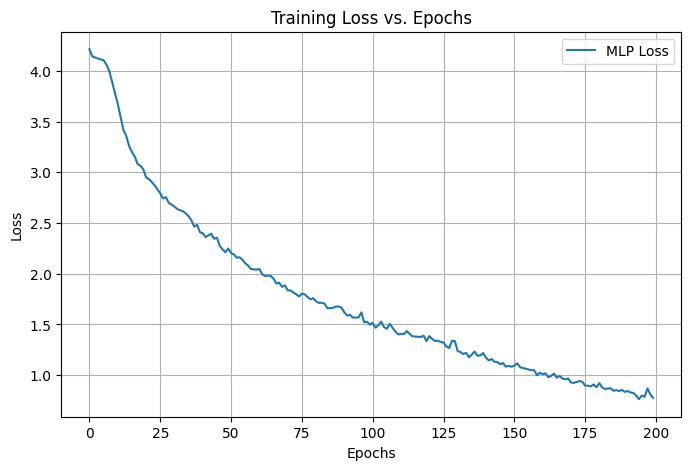

In [34]:
plt.figure(figsize=(8,5))
plt.plot(clf_2.loss_curve_,label='MLP Loss')
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix

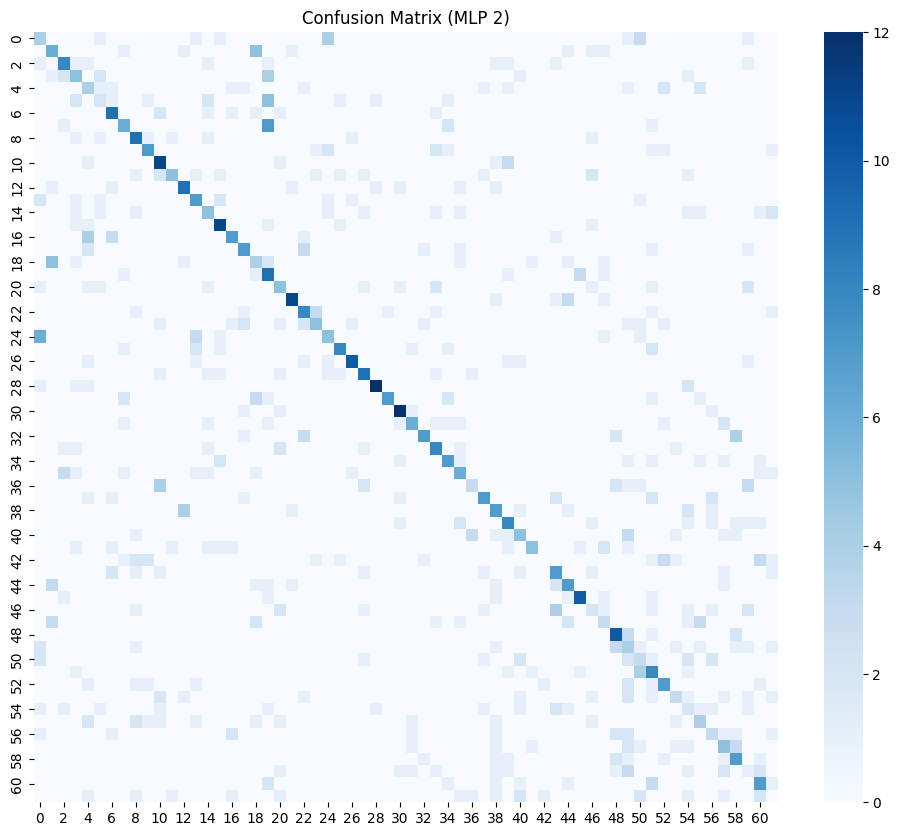

In [45]:
plt.figure(figsize=(12,10))
cm=confusion_matrix(y_test,y_pred_clf2)
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix (MLP 2)')
plt.show()

ROC Curve (Micro Average)

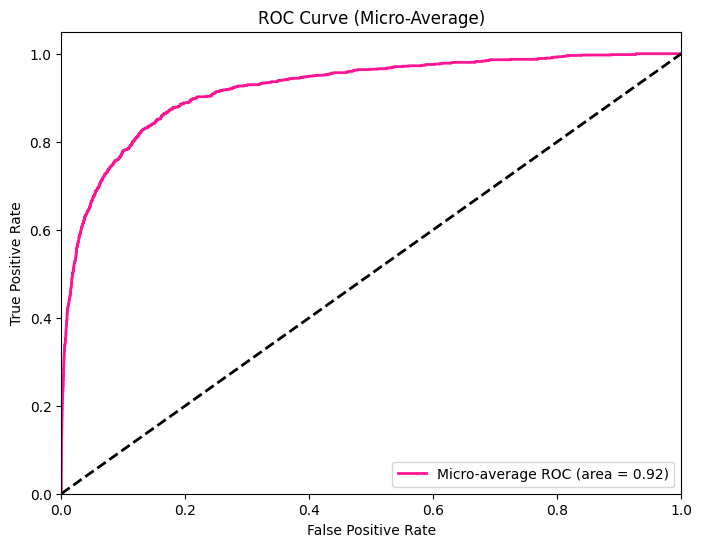

In [50]:
y_test_bin=label_binarize(y_test, classes=range(62))
y_score=clf_2.predict_proba(X_test)

fpr,tpr,_ = roc_curve(y_test_bin.ravel(),y_score.ravel())
roc_auc=auc(fpr,tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Micro-average ROC (area = {roc_auc:.2f})', color='deeppink', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-Average)')
plt.legend(loc="lower right")
plt.show()

